In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_copy import TripletModel, validate_model, train_model, get_base_rod
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
from jaxtyping import Float


def inv_softplus(y: jax.Array) -> jax.Array:
    return jnp.log(jnp.expm1(y))


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, out_features: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, out_features, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jnp.ravel(x)
        x = jax.nn.tanh(self.layer1(x))
        x = self.layer2(x)
        return x   # shape (3,)


class Example(TripletModel):
    theta: jax.Array   # [raw_scale, raw_ratio, raw_beta]
    mlp: MLP
    rho: float
    beta_max: float
    corr_scale: float
    l_k: float   # <-- NEW

    def __init__(
        self,
        der_K: jax.Array,
        key: jax.Array,
        l_k: float,
        rho: float = 3.5,
        beta_max: float = 0.8,
        corr_scale: float = 1e-2,
    ):
        """
        der_K = [k_ss, k_sb, k_bb] (PHYSICAL values)

        l_k rescales stiffness:
            k_ss <- l_k * k_ss
            k_bb <- k_bb / l_k
        """
        der_K = jnp.ravel(der_K)
        if der_K.shape != (3,):
            raise ValueError(f"Expected der_K shape (3,), got {der_K.shape}")

        k_ss0, k_sb0, k_bb0 = der_K
        eps = 1e-6

        # ---- undo scaling to get base stiffness ----
        k_ss_base = k_ss0 / l_k
        k_bb_base = k_bb0 * l_k
        k_sb_base = k_sb0

        if k_ss_base <= 0 or k_bb_base <= 0:
            raise ValueError("Need positive base stiffness.")

        if k_ss_base * k_bb_base - 2.0 * k_sb_base**2 <= 0:
            raise ValueError("Base stiffness must be strictly PD.")

        # ---- convert to bounded parameterization ----
        s0 = k_bb_base
        r0 = k_ss_base / k_bb_base
        beta0 = jnp.sqrt(2.0) * k_sb_base / jnp.sqrt(k_ss_base * k_bb_base)

        log_r0 = jnp.log(r0)
        if jnp.abs(log_r0) >= rho:
            raise ValueError(
                f"Base ratio outside allowed range. "
                f"Try increasing rho or adjusting l_k."
            )

        if jnp.abs(beta0) >= beta_max:
            raise ValueError("Coupling too large for beta_max.")

        raw_scale0 = inv_softplus(s0 - eps)
        raw_ratio0 = jnp.arctanh(jnp.clip(log_r0 / rho, -0.999999, 0.999999))
        raw_beta0 = jnp.arctanh(jnp.clip(beta0 / beta_max, -0.999999, 0.999999))

        self.theta = jnp.array([raw_scale0, raw_ratio0, raw_beta0])
        self.mlp = MLP(in_features=5, hidden_size=10, out_features=3, key=key)
        self.rho = rho
        self.beta_max = beta_max
        self.corr_scale = corr_scale
        self.l_k = l_k

    def _bounded_parameters(self, del_strain):
        eps = 1e-6
        x = jnp.ravel(del_strain)

        dtheta = self.corr_scale * self.mlp(x)
        theta = self.theta + dtheta

        s = jax.nn.softplus(theta[0]) + eps
        log_r = self.rho * jnp.tanh(theta[1])
        r = jnp.exp(log_r)
        beta = self.beta_max * jnp.tanh(theta[2])

        return s, r, beta

    def get_K_entries(self, del_strain):
        # ---- base (well-conditioned) stiffness ----
        s, r, beta = self._bounded_parameters(del_strain)

        k_bb_base = s
        k_ss_base = s * r
        k_sb_base = beta * s * jnp.sqrt(r / 2.0)

        # ---- apply physical scaling ----
        k_ss = self.l_k * k_ss_base
        k_bb = k_bb_base / self.l_k
        k_sb = k_sb_base

        return jnp.array([k_ss, k_sb, k_bb])

    def get_K_matrix(self, del_strain):
        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)
        return jnp.array([
            [k_ss, 0.0,  k_sb],
            [0.0,  k_ss, k_sb],
            [k_sb, k_sb, k_bb],
        ])

    def __call__(self, del_strain):
        del_strain = jnp.ravel(del_strain)

        e0 = del_strain[0]
        e1 = del_strain[1]
        eb = del_strain[3]

        k_ss, k_sb, k_bb = self.get_K_entries(del_strain)

        stretching_energy = 0.5 * k_ss * (e0**2 + e1**2)
        coupling_energy = k_sb * (e0 + e1) * eb
        bending_energy = 0.5 * k_bb * eb**2

        return stretching_energy + coupling_energy + bending_energy

actually, the scaling should be :
k_ss *= r0^2*l_k
k_bb /= l_k

In [3]:
from util import TestCase

train_file = "data/output_train.npz"
valid_file = "data/output_valid.npz"
# train_file = "data/output.npz"
# valid_file = "data/output_train.npz"

# validate_model(Example)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_file, valid_file=valid_file, n_epochs=500, lr=1e-2, init_K=jnp.array([1, 0.001, 0.5]) )
# final_model, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file="output_valid.npz", valid_file="output_valid.npz", n_epochs=100, lr=1e-2)

print( "initial K: ", init_K)
print( "learned K: ", final_model.get_K_entries(jnp.zeros(5)) )

Step 0    | LR: 1.000e-02  | Train: 2.94713e-04  | Valid: 1.72455e-03  | K: [1.06622947 0.00726372 0.48776665]
Step 10   | LR: 9.991e-03  | Train: 1.40322e-04  | Valid: 1.30210e-03  | K: [1.57781297 0.05311927 0.39569444]
Step 20   | LR: 9.965e-03  | Train: 1.02792e-04  | Valid: 1.13533e-03  | K: [1.56593195 0.0247787  0.32976805]
Step 30   | LR: 9.921e-03  | Train: 8.81035e-05  | Valid: 3.32342e-03  | K: [1.56272885 0.01369552 0.28664433]
Step 40   | LR: 9.859e-03  | Train: 7.53375e-05  | Valid: 3.21333e-03  | K: [1.62464742 0.01375977 0.25388898]
Step 50   | LR: 9.781e-03  | Train: 5.50455e-05  | Valid: 3.05147e-03  | K: [1.62486046 0.01202443 0.2305783 ]
Step 60   | LR: 9.685e-03  | Train: 1.23588e-05  | Valid: 3.10231e-03  | K: [ 1.42224283 -0.01123365  0.21022263]
Step 70   | LR: 9.573e-03  | Train: 6.55778e-06  | Valid: 3.22260e-03  | K: [ 1.27731617 -0.033238    0.20012658]
Step 80   | LR: 9.446e-03  | Train: 2.33127e-06  | Valid: 3.24909e-03  | K: [ 1.30701028 -0.02763748  0.20

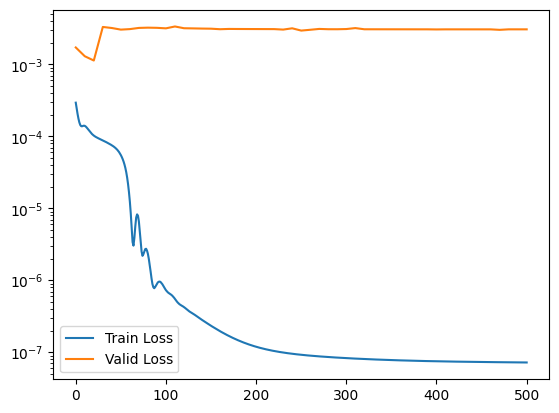

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
train = TestCase.from_npz(train_file)
valid = TestCase.from_npz(valid_file)
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[0])

base, aux0, _, _ = get_base_rod()
rods = base.with_bc(valid.bc)
# pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
pred, aux = rods.solve_with_aux(final_model, lambdas, aux0, max_dlambda=5e-3, iters=5, ls_steps=10)

del_strains = rods.get_del_strain_history(pred, aux)
print(del_strains.shape)

(1, 11, 1, 5)


In [6]:
base, aux, _, _ = get_base_rod()
rods = base.with_bc(train.bc)
# pred = rods.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)[0]
pred_train, aux_train = rods.solve_with_aux(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)

del_strains_train = rods.get_del_strain_history(pred_train, aux_train)
# concatenate del_strains and del_strains_train along the time axis for visualization

print(del_strains_train.shape)
print(del_strains[0,:,0,:].shape)
del_strains_combined =[del_strains_train[0,:,0,:], del_strains[0,:,0,:]]

(1, 11, 1, 5)
(11, 5)


### Visualizing Energy landscape

(1, 11, 1, 5)


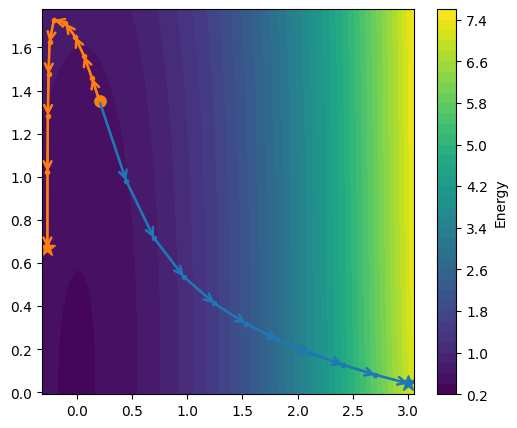

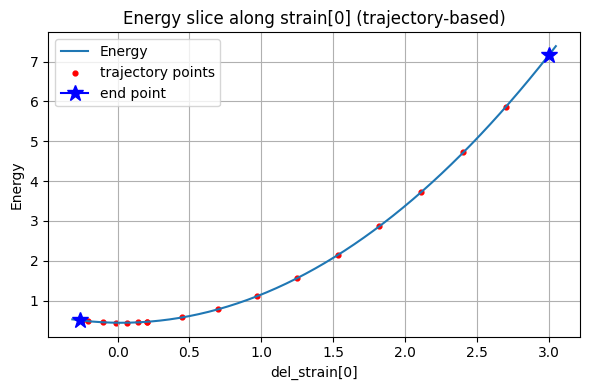

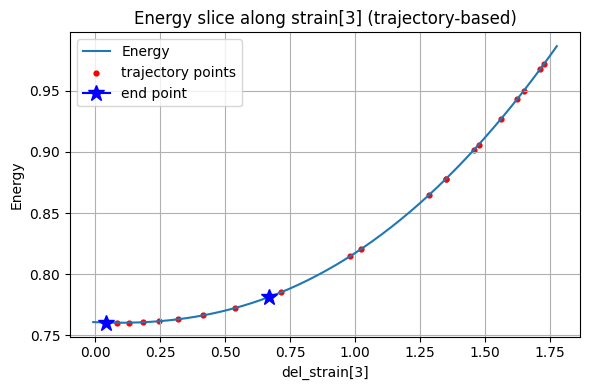

In [7]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


def plot_energy_2d_from_traj(
    model,
    strain_trajs,   # list of arrays, each (Ni, 5), or single array (N, 5)
    idx1,
    idx2,
    pad=0.05,
    n=200,
    center="mean",
):
    import jax
    import jax.numpy as jnp
    import numpy as np
    import matplotlib.pyplot as plt

    # allow either one trajectory or a list of trajectories
    if isinstance(strain_trajs, (list, tuple)):
        traj_list = [jnp.asarray(tr) for tr in strain_trajs]
        all_strains = jnp.concatenate(traj_list, axis=0)
    else:
        traj_list = [jnp.asarray(strain_trajs)]
        all_strains = traj_list[0]

    # choose reference strain
    if center == "mean":
        strain_ref = jnp.mean(all_strains, axis=0)
    else:
        strain_ref = all_strains[center]

    # ranges from all data
    s1_data_all = all_strains[:, idx1]
    s2_data_all = all_strains[:, idx2]

    s1_vals = jnp.linspace(s1_data_all.min() - pad, s1_data_all.max() + pad, n)
    s2_vals = jnp.linspace(s2_data_all.min() - pad, s2_data_all.max() + pad, n)

    S1, S2 = jnp.meshgrid(s1_vals, s2_vals, indexing="xy")

    def energy_at(s1, s2):
        strain = strain_ref
        strain = strain.at[idx1].set(s1)
        strain = strain.at[idx2].set(s2)
        return model(strain)

    E = jax.vmap(
        lambda row_s1, row_s2: jax.vmap(energy_at)(row_s1, row_s2)
    )(S1, S2)

    # convert to numpy
    S1_np = np.array(S1)
    S2_np = np.array(S2)
    E_np = np.array(E)

    plt.figure(figsize=(6, 5))
    cp = plt.contourf(S1_np, S2_np, E_np, levels=40)
    plt.colorbar(cp, label="Energy")

    for k, traj in enumerate(traj_list):
        s1 = np.array(traj[:, idx1])
        s2 = np.array(traj[:, idx2])

        color = f"C{k}"  # different color per trajectory (optional)

        # main trajectory
        plt.plot(
            s1, s2,
            "-o",
            ms=3,
            lw=1.5,
            color=color,
            label="trajectory" if k == 0 else None
        )

        # start point (circle)
        plt.plot(
            s1[0], s2[0],
            marker="o",
            markersize=8,
            color=color,
            linestyle="None",
            label="start" if k == 0 else None
        )

        # end point (star)
        plt.plot(
            s1[-1], s2[-1],
            marker="*",
            markersize=12,
            color=color,
            linestyle="None",
            label="end" if k == 0 else None
        )

        # arrows for direction (use differences between consecutive points)
        # arrows for direction
        step = max(1, len(s1) // 12)   # fewer, clearer arrows

        for i in range(0, len(s1) - 1, step):
            plt.annotate(
                "",
                xy=(s1[i+1], s2[i+1]),
                xytext=(s1[i], s2[i]),
                arrowprops=dict(
                    arrowstyle="->",
                    color=color,
                    lw=1.8,
                    shrinkA=0,
                    shrinkB=0,
                    mutation_scale=14,
                ),
                zorder=5,
            )

def plot_energy_1d_from_traj(
    model,
    strain_trajs,   # array (N, 5) or list of arrays [(N1, 5), (N2, 5), ...]
    idx,
    pad=0.05,
    n=200,
    center="mean",   # "mean" or int
):
    """
    Plot E along one strain direction using trajectory data.

    Args:
        model: trained model
        strain_trajs: single trajectory array (N, d) or list/tuple of arrays
        idx: strain component index to plot
        pad: padding around trajectory range
        n: number of samples in 1D slice
        center: "mean" or int index into the concatenated data
    """

    # Allow either one trajectory or multiple separate trajectories
    if isinstance(strain_trajs, (list, tuple)):
        traj_list = [jnp.asarray(tr) for tr in strain_trajs]
        all_strains = jnp.concatenate(traj_list, axis=0)
    else:
        traj_list = [jnp.asarray(strain_trajs)]
        all_strains = traj_list[0]

    # Reference strain
    if center == "mean":
        strain_ref = jnp.mean(all_strains, axis=0)
    else:
        strain_ref = all_strains[center]

    # Range from all data
    s_data_all = all_strains[:, idx]
    s_vals = jnp.linspace(s_data_all.min() - pad, s_data_all.max() + pad, n)

    def energy_at(s):
        strain = strain_ref
        strain = strain.at[idx].set(s)
        return model(strain)

    E = jax.vmap(energy_at)(s_vals)

    plt.figure(figsize=(6, 4))
    plt.plot(np.array(s_vals), np.array(E), label="Energy")

    # Overlay each trajectory separately
    for k, traj in enumerate(traj_list):
        s_data = traj[:, idx]
        E_data = jax.vmap(energy_at)(s_data)

        s_np = np.array(s_data)
        E_np = np.array(E_data)

        # scatter points
        plt.scatter(
            s_np,
            E_np,
            c="red",
            s=12,
            label="trajectory points" if k == 0 else None,
        )

        # ⭐ mark endpoint
        plt.plot(
            s_np[-1],
            E_np[-1],
            marker="*",
            markersize=12,
            color="blue",
            label="end point" if k == 0 else None,
        )


    plt.xlabel(f"del_strain[{idx}]")
    plt.ylabel("Energy")
    plt.title(f"Energy slice along strain[{idx}] (trajectory-based)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print(del_strains.shape)
strain_traj = del_strains_combined   # shape (11, 5)
# print(strain_traj.shape)

plot_energy_2d_from_traj(final_model, strain_traj, idx1=0, idx2=3)
plot_energy_1d_from_traj(final_model, strain_traj, idx=0)
plot_energy_1d_from_traj(final_model, strain_traj, idx=3)

TripletState(t=(1, 2, 3), d1=(1, 2, 3), beta=(1,))


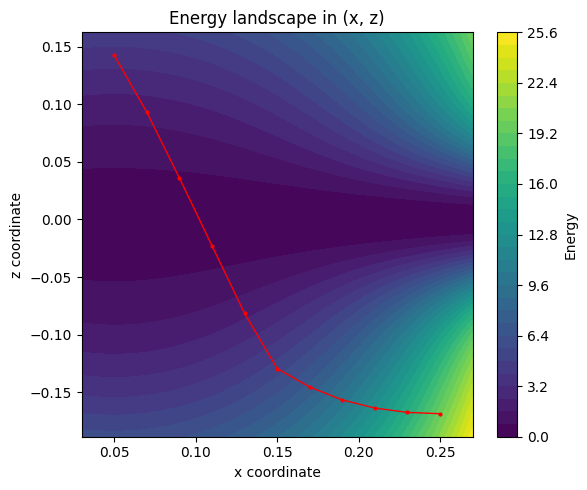

In [8]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import tree_util

print(tree_util.tree_map(
    lambda x: getattr(x, "shape", None),
    aux
))

# choose one reference configuration
case_idx = 0
time_idx = -1

q_ref = pred[case_idx, time_idx]
lam_ref = lambdas[time_idx]

x_traj = pred[case_idx, :, 4]
z_traj = pred[case_idx, :, 6]

x_pad = 0.02
z_pad = 0.02

x_vals = jnp.linspace(x_traj.min() - x_pad, x_traj.max() + x_pad, 120)
z_vals = jnp.linspace(z_traj.min() - z_pad, z_traj.max() + z_pad, 120)

X, Z = jnp.meshgrid(x_vals, z_vals, indexing="ij")

def set_xz_and_eval_energy(x, z):
    q = q_ref.at[4].set(x)
    q = q.at[6].set(z)
    return rods.get_E(lam_ref, q, final_model, aux0)

E = jax.vmap(
    lambda xrow, zrow: jax.vmap(set_xz_and_eval_energy)(xrow, zrow)
)(X, Z)

plt.figure(figsize=(6, 5))
cf = plt.contourf(X, Z, E, levels=40)
plt.xlabel("x coordinate")
plt.ylabel("z coordinate")
plt.title("Energy landscape in (x, z)")
plt.colorbar(cf, label="Energy")

plt.plot(pred[case_idx, :, 4], pred[case_idx, :, 6], 'r.-', markersize=4, linewidth=1)

plt.tight_layout()
plt.show()

In [9]:
print(pred.shape)
animate(pred[0,:])

(1, 11, 11)


In [10]:
animate(valid.qs)

(1, 11, 11)


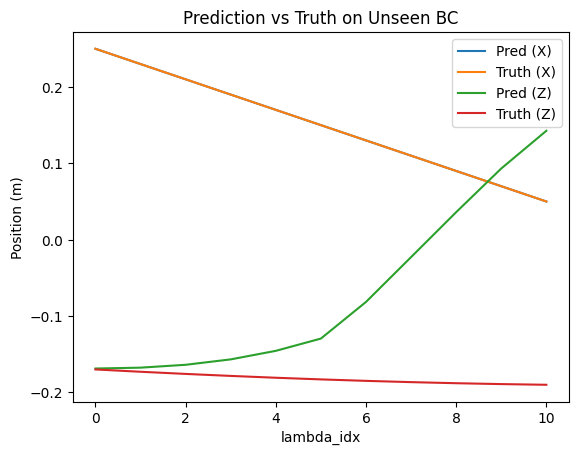

In [11]:
import matplotlib.pyplot as plt
print(pred.shape)

plt.plot(pred[0, :, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[0, :, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[0, :, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.xlabel("lambda_idx")
plt.ylabel("Position (m)")
plt.show()

In [12]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [0.5 0.  0. ]
final:  [2. 0. 0.]
Validation BC:
init:  [0.5 0.  0. ]
final:  [0.1 0.  0. ]


In [13]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the training data:  [ 1.00000029e+00  2.24749083e-07 -2.05793567e-02]


In [14]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [ 2.50000000e-01  3.61652220e-12 -1.69941712e-01]
final position of the middle node in the validation data:  [ 5.00171415e-02  5.53160840e-06 -1.90022059e-01]


In [15]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.70005689e-01 -6.74989598e-05 -1.45570583e-01  0.00000000e+00
   3.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.50006937e-01 -3.24195694e-04 -1.29501475e-01  0.00000000e+00
   3.00000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.30007484e-01 -1.09279649e-01 -8.15173620e-02  0.00000000e+00
   2.60000000e-01  0.00000000e+00  0.00000000e+00]]
final position of the middle node in the prediction:  [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.70005689e-01 -6.74989598e-05 -1.45570583e-01  0.00000000e+00
   3.40000000e-01  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.50006937e-01 -3.24195694e-04 -1.29501475e-01  0.00000000e+00
   3.00000000e-01  0.0000